In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

### Task 1: load in the spotify dataset

In [2]:
df = pd.read_csv('spotify_data.csv')

### Task 2: preview the dataset

In [3]:
df.head()

,tempo,danceability,energy,instrumentalness,liveness,valence
0,156.985,0.831,0.814,0.013400,0.0556,0.3890
1,115.080,0.719,0.493,0.000000,0.1180,0.1240
2,218.050,0.850,0.893,0.000004,0.3720,0.0391
3,186.948,0.476,0.781,0.000000,0.1140,0.1750
4,147.988,0.798,0.624,0.000000,0.1660,0.5910


### Task 3: select the relevant column


In [4]:
song_tempos = df.tempo

### Task 5: plot the population distribution with the mean labeled

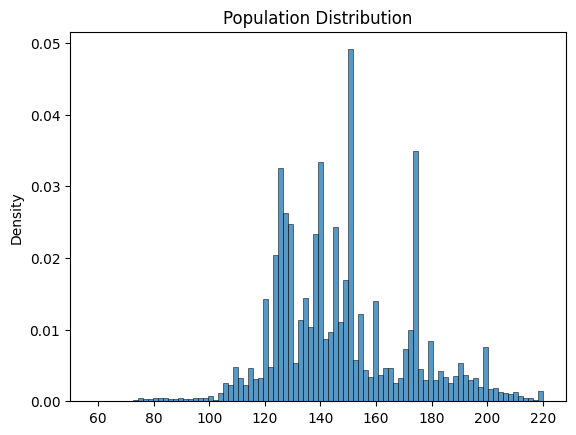

<Figure size 640x480 with 0 Axes>

In [5]:
# plot the population distribution
sns.histplot(song_tempos, stat='density')
# informative title for the distribution 
plt.title(f"Population Distribution")
# remove None label
plt.xlabel('')
plt.show()
plt.clf()

### Task 6: sampling distribution of the sample mean

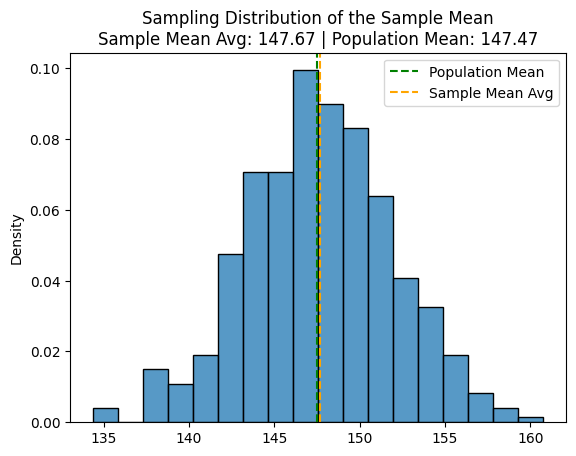

<Figure size 640x480 with 0 Axes>

In [6]:
sample_stats = []
for i in range(500):
    samp = np.random.choice(song_tempos, 30, replace=False)
    sample_mean = np.mean(samp)
    sample_stats.append(sample_mean)

pop_statistic = round(np.mean(song_tempos), 2)

sns.histplot(sample_stats, stat='density')

plt.title(f"Sampling Distribution of the Sample Mean\n"
          f"Sample Mean Avg: {round(np.mean(sample_stats),2)} | "
          f"Population Mean: {pop_statistic}")

plt.axvline(pop_statistic, color='g', linestyle='dashed', label='Population Mean')
plt.axvline(np.mean(sample_stats), color='orange', linestyle='dashed', label='Sample Mean Avg')
plt.legend()
plt.show()
plt.clf()

### Task 7: Compare your sampling distribution of the sample means to the population mean. Is the sample mean an unbiased or biased estimator of the population?

The sample mean is an unbiased estimator of the population mean.

Reason:

- The average of the 500 sample means is very close to the true population mean

- This happens because, mathematically, the expected value of the sample mean equals the population mean.

- The plot confirms it: the orange dashed line (sample mean avg) aligns with the green dashed line (population mean).

### Task 8: sampling distribution of the sample minim

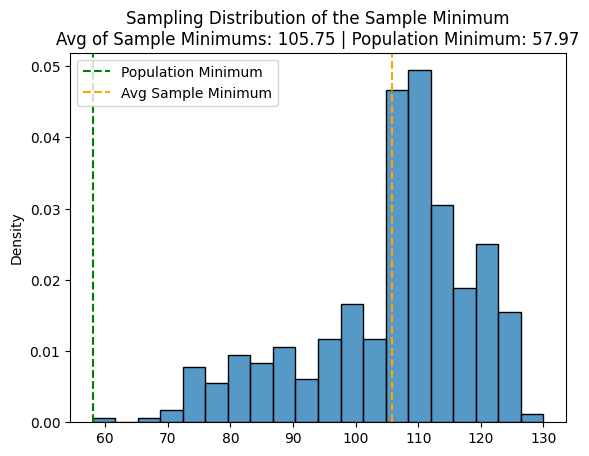

<Figure size 640x480 with 0 Axes>

In [7]:
sample_stats = []
for i in range(500):
    samp = np.random.choice(song_tempos, 30, replace=False)
    sample_min = np.min(samp)
    sample_stats.append(sample_min)

pop_statistic = round(np.min(song_tempos), 2)

sns.histplot(sample_stats, stat='density')

plt.title(f"Sampling Distribution of the Sample Minimum\n"
          f"Avg of Sample Minimums: {round(np.mean(sample_stats),2)} | "
          f"Population Minimum: {pop_statistic}")

plt.axvline(pop_statistic, color='g', linestyle='dashed', label='Population Minimum')
plt.axvline(np.mean(sample_stats), color='orange', linestyle='dashed', label='Avg Sample Minimum')
plt.legend()
plt.show()
plt.clf()

### Task 9: Compare your sampling distribution of the sample minimums to the population minimum. Is the sample minimum an unbiased or biased estimator of the population?

The sample mean is an biased estimator of the population mean.

Reason:

- The average of the 500 sample minimums is much larger than the true population minimum.

- This happens because each sample only contains 30 values, so it is unlikely to capture the absolute smallest value in the whole population.

- The plot confirms it: the orange dashed line (average sample minimum) is shifted to the right of the green dashed line (population minimum).

### Task 10: sampling distribution of the sample variance

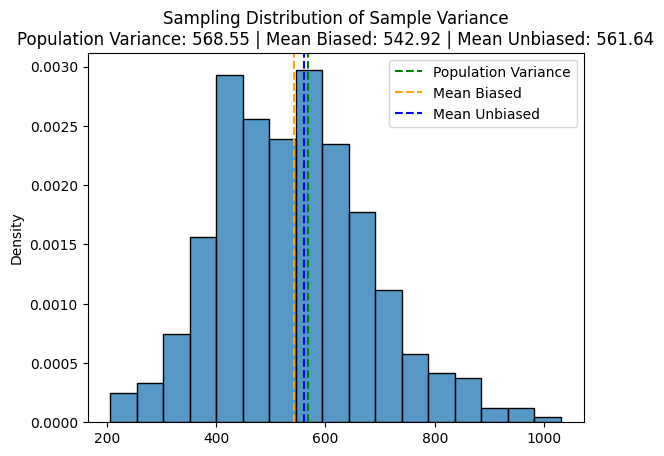

<Figure size 640x480 with 0 Axes>

In [8]:
sample_stats_biased = []
sample_stats_unbiased = []

for i in range(500):
    samp = np.random.choice(song_tempos, 30, replace=False)
    sample_stats_biased.append(np.var(samp))          # ddof=0
    sample_stats_unbiased.append(np.var(samp, ddof=1)) # ddof=1

pop_statistic = np.var(song_tempos)  # population variance

# Use biased sample histogram for the bars
sns.histplot(sample_stats_biased, stat='density')

plt.title(
    f"Sampling Distribution of Sample Variance\n"
    f"Population Variance: {pop_statistic:.2f} | "
    f"Mean Biased: {np.mean(sample_stats_biased):.2f} | "
    f"Mean Unbiased: {np.mean(sample_stats_unbiased):.2f}"
)

# Vertical lines
plt.axvline(pop_statistic, color='g', linestyle='dashed', label='Population Variance')
plt.axvline(np.mean(sample_stats_biased), color='orange', linestyle='dashed', label='Mean Biased')
plt.axvline(np.mean(sample_stats_unbiased), color='blue', linestyle='dashed', label='Mean Unbiased')

plt.legend()
plt.show()
plt.clf()


### Task 11 & 12

The mean of the sample variances is consistently slightly less than the population variance, meaning it is a **biased estimator**. However, it is very close. Let’s dig into this.

We calculated the sample variance the same way we calculate population variance. However, the formulas for sample variance and population variance are actually distinct.

As we have seen, **population variance** is calculated as:

$$
\text{Population Variance} = \frac{\sum (\text{observation} - \mu)^2}{n}
$$


When we measure the sample variance using the same formula, it turns out that we tend to **underestimate the population variance**. 

To correct this, we divide by \(n-1\) instead of \(n\):

$$
\text{Population Variance} = \frac{\sum (\text{observation} - \text{sample mean})^2}{n - 1}
$$

Using this formula, the **sample variance becomes an unbiased estimator** of the population variance.

### Task 13: calculate the population mean and standard deviation

In [9]:
population_mean = np.mean(song_tempos)
print("Population Mean: " + str(round(population_mean,2)))

population_std = np.std(song_tempos)
print("Population Standard Deviation: " + str(round(population_std,2)))

Population Mean: 147.47
Population Standard Deviation: 23.84


### task 14: calculate the standard error

In [10]:
standard_error = population_std / np.sqrt(30)

print("Standard Error: " + str(round(standard_error,2)))

Standard Error: 4.35


### Task 15: calculate the probability of observing an average tempo of 140bpm or lower from a sample of 30 songs

In [11]:
prop = stats.norm.cdf(140, population_mean, standard_error)

print(f"Probability: {prop*100:.2f}%")

Probability: 4.30%


# Task 16: calculate the probability of observing an average tempo of 150bpm or higher from a sample of 30 songs

In [12]:
prop = 1 - stats.norm.cdf(150, population_mean, standard_error)

print(f"Probability: {prop*100:.2f}%")

Probability: 28.09%


### Extra: Use the sampling distribution of the sample minimum to estimate the probability of observing a specific sample minimum. For example, from the plot, what is the chance of getting a sample minimum that is less than 130bpm?

In [57]:
sample_mins = []
bpm = 100

for i in range(500):
    sample = np.random.choice(song_tempos, 30, replace=False)
    sample_mins.append(np.min(sample))

sample_mins = np.array(sample_mins)

prob = np.mean(sample_mins < bpm) * 100

print(f"Probability that sample minimum < {bpm} bpm : {prob:.2f}%")

Probability that sample minimum < 100 bpm : 28.40%
